# Running The Model
This is where we show how to run the model we made and where we do so in various configurations. Each second level heading is a new model demonstration.

In [17]:
from enum import IntEnum, auto
from dataclasses import dataclass
import functools as ft
from typing import Protocol, Generator, Any, Iterator, Callable, Union
from random import Random


type Category = IntEnum

class safe_category(IntEnum):
    unsafe = auto()
    safe = auto()

class Hypothesis:
    "A function that accepts a stimulus, and categorizes it between two categories"

    lower_category:safe_category = safe_category.unsafe
    upper_category:safe_category = safe_category.safe

    min_bound:float = 0
    max_bound:float = 1

    def __init__(self, category_boundary: float) -> None:
        assert category_boundary >= Hypothesis.min_bound
        assert category_boundary <= Hypothesis.max_bound

        self.category_boundary: float = category_boundary
    
    def eval(self, stimulus: float) -> safe_category:
        return Hypothesis.lower_category if stimulus < self.category_boundary else Hypothesis.upper_category

######################################################[ Manage Storing Data ]###################################################################

@dataclass(frozen=True,slots=False)
class Datapoint:
    position: float
    category: safe_category

class HistoryManager:
    "This manages the history of observations seen, and implements any memory restrictions assumend in the model."

    def __init__(self, max_memory_length:int|None) -> None:
        self.contents:list[Datapoint] = []
        self.max_memory_length:int|None = max_memory_length
    
    def __iter__(self)->Iterator[Datapoint]:
        return self.contents.__iter__()
    
    def add(self,data:Datapoint)-> None:
        self.contents.append(data)
        while self.max_memory_length is not None and self.max_memory_length > len(self.contents):
            self.contents.pop(0)

#########################################################[ Hypothesis updater ]#######################################################################

def get_plausible_hyposthesis_boundaries(data_list:HistoryManager)->tuple[float,float]:
    lower_category_data = [d.position for d in data_list if d.category == Hypothesis.lower_category]
    upper_category_data = [d.position for d in data_list if d.category == Hypothesis.upper_category]
    lower_category_data.append(Hypothesis.min_bound)
    upper_category_data.append(Hypothesis.max_bound)

    max_lower_position = max(lower_category_data)
    min_upper_position = min(upper_category_data)

    return (max_lower_position, min_upper_position)

type HypothesisUpdater = Generator[Hypothesis,Any,None]

def UpdateConsistantWithData(data_list:HistoryManager,rand:Random=Random())-> Generator[Hypothesis,None,None]:
    "Selects a new hypothesis uniformly at random from all prior hypotheses"
    
    while True:
        min_pos, max_pos = get_plausible_hyposthesis_boundaries(data_list)
        boundary = rand.uniform(min_pos,max_pos)
        yield Hypothesis(category_boundary=boundary)

###############################################[ Stimulus Selection Strategy ]#########################################################
        
# type StimulusSelector = Callable[[],float]
class StimulusSelector(Protocol):
    def select_stimulus(self,current_hypothesis:Hypothesis)->float:
        ...

class Random_StimulusSelector:
    def __init__(self, random:Random=Random()) -> None:
        "Sampling bias is how far from the current"
        self.rand = random

    def select_stimulus(self,current_hypothesis:Hypothesis)->float:
        lower=Hypothesis.min_bound
        upper=Hypothesis.max_bound
        return self.rand.uniform(lower, upper)
    
class HistoricallyInformedRandom_StimulusSelector:
    def __init__(self, history:HistoryManager, random:Random=Random()) -> None:
        "Sampling bias is how far from the current"
        self.rand = random
        self.history = history

    def select_stimulus(self,current_hypothesis:Hypothesis)->float:
        lower, upper = get_plausible_hyposthesis_boundaries(self.history)
        return self.rand.uniform(lower, upper)

class HypothesisOffset_StimulusSelector:
    def __init__(self, sampling_bias:float,random:Random=Random()) -> None:
        "Sampling bias is how far from the current"
        self.rand = random
        self.sampling_bias=sampling_bias

    def select_stimulus(self,current_hypothesis:Hypothesis)->float:
        lower=Hypothesis.min_bound
        upper=Hypothesis.max_bound
        lower = max(lower, current_hypothesis.category_boundary - self.sampling_bias)
        upper = min(upper, current_hypothesis.category_boundary + self.sampling_bias)
        return self.rand.uniform(lower, upper)

class HistoricallyInformedHypothesisOffset_StimulusSelector:
    def __init__(self, sampling_bias:float, history:HistoryManager, random:Random=Random()) -> None:
        "Sampling bias is how far from the current"
        self.rand = random
        self.sampling_bias=sampling_bias
        self.history = history

    def select_stimulus(self,current_hypothesis:Hypothesis)->float:
        lower, upper = get_plausible_hyposthesis_boundaries(self.history)
        lower = max(lower, current_hypothesis.category_boundary - self.sampling_bias)
        upper = min(upper, current_hypothesis.category_boundary + self.sampling_bias)
        return self.rand.uniform(lower, upper)

#############################################################[ Archive Content ]#############################################################

@dataclass(frozen=True, slots=False)
class New_Datapoint_Archive:
    datapoint:Datapoint
@dataclass(frozen=True, slots=False)
class New_Hypothesis_Archive:
    hypothesis:Hypothesis

type Archive= Union[New_Datapoint_Archive, New_Hypothesis_Archive]

###################################################[ Hypothesis Bank ]################################################################
    
class HypothesisBank(Protocol):
    "These classes are what is used to determine when a hypothesis should be updated and how."
    def learn_data(self,data:Datapoint) -> None:
        ...
    def predict_categorization(self, stimulus: float) -> safe_category:
        ...
    def suggest_stimulus(self) -> float:
        ...
    def get_hypothesis_archive(self)->list[Archive]:
        ...
    def get_hypothesis_archive_as_string(self)->str:
        ...
    

# @dataclass
# class MultiHypothesisBankConfig:
#     num_hypotheses: int
#     "The total number of hypotheses that the model considers at once"
#     num_hypotheses_kept: int
#     """
#     The total number of hypotheses that the model keeps between run itterations. 
#     This number should be < num_hypotheses or no hypotheses will be updated between trials. 
#     """

# class Multi_HypothesisBank(HypothesisBank):
#     def __init__(self, config:MultiHypothesisBankConfig) -> None:
#         self.active_hypotheses:list[Hypothesis] = []
#         self.config = config

class ReplaceWhenWrong_HypothesisBank(HypothesisBank):
    def __init__(self,history:HistoryManager, updater:HypothesisUpdater, selector:StimulusSelector, initial_hypothesis:Hypothesis|None=None) -> None:
        self.history = history
        self.updater = updater
        self.selector = selector
        self.archive:list[Archive] = []

        self.active_hypothesis:Hypothesis = next(self.updater) # Need this to start the iterator.
        if initial_hypothesis is not None: self.active_hypothesis = initial_hypothesis

        self.archive.append(New_Hypothesis_Archive(self.active_hypothesis))

    def learn_data(self,data:Datapoint) -> None:
        "This method represents the model getting data from the environment. If this conflicts with the current model, it will replace it."
        self.history.add(data)
        self.archive.append(New_Datapoint_Archive(data))

        # Update the active hypothesis if it is inconsistant with the data.
        if self.active_hypothesis.eval(stimulus=data.position) != data.category:
            self.active_hypothesis = next(self.updater)
            self.archive.append(New_Hypothesis_Archive(self.active_hypothesis))

    def predict_categorization(self, stimulus: float) -> safe_category:
        "Given the currently accepted hypothesis, how would we expect the current stimulus be categorized."
        return self.active_hypothesis.eval(stimulus=stimulus)
    
    def suggest_stimulus(self) -> float:
        "Given the current history, what stimulus would be the best"
        return self.selector.select_stimulus(self.active_hypothesis)
    
    def get_hypothesis_archive(self)->list[Archive]:
        return self.archive
    
    def get_hypothesis_archive_as_string(self)->str:
        out = []
        for e in self.get_hypothesis_archive():
            if   isinstance(e, New_Datapoint_Archive):
                out.append(f"DATA: learned {e.datapoint.position} in Category '{e.datapoint.category.name}'")
            elif isinstance(e, New_Hypothesis_Archive):
                out.append(f"HYPOTHESIS: new boundary at {e.hypothesis.category_boundary}")
            else:
                out.append(f"???: Archive note not recognized. `{e}`")
        return "\n".join(out)

### Create a way to Display Results

In [25]:
@dataclass(frozen=True,slots=False)
class iteration_results:
    model: ReplaceWhenWrong_HypothesisBank
    true_boundary: float
    evaluated_stimulus: float
    evaluated_category: safe_category
    model_initial_boundary: float
    model_final_boundary: float
    model_boundary_changed: bool


def run_itteration(model:ReplaceWhenWrong_HypothesisBank,
                   selected_stimulus: float|None,
                   true_hypothesis: Hypothesis) -> iteration_results:
    "Run an itteration of the learning loop. For yoked, provide a `selected_stimulus` if it is NONE, then the model will select it for you."
    
    hi = model.active_hypothesis.category_boundary
    stimulus = selected_stimulus if selected_stimulus is not None else model.suggest_stimulus()
    category = true_hypothesis.eval(stimulus)
    data = Datapoint(position=stimulus, category=category)
    model.learn_data(data)
    hf = model.active_hypothesis.category_boundary
    hypothesis_changed = isinstance(model.get_hypothesis_archive()[-1], New_Hypothesis_Archive) 
    # we know we will get a new datapoint, only new hypothesis if hypothesis change occours. I don't want to deal with floating point error with ==.

    return iteration_results(
        model=model,
        true_boundary=true_hypothesis.category_boundary,
        evaluated_stimulus= stimulus,
        evaluated_category= category,
        model_initial_boundary= hi,
        model_final_boundary= hf,
        model_boundary_changed= hypothesis_changed
    )

@dataclass(frozen=True,slots=False)
class experiment_results:
    model:ReplaceWhenWrong_HypothesisBank
    iterations:list[iteration_results]
    was_yoked:bool
    yoked_to:experiment_results|None

def run_experiment(models:list[ReplaceWhenWrong_HypothesisBank], true_hypothesis:Hypothesis, num_iterations:int)->list[experiment_results]:
    """
    Runs an experiment for `num_iterations` iterations, and then returns all results. 
    It is assumed that the 0-index model will get to choose the stimuli observed, and models at all other indicies will be yoked to it.
    """
    iterations = [[] for _ in models]

    # Run all experiments
    for it in range(num_iterations):
        stimulus = models[0].suggest_stimulus() # Run all as yoked, but yoke the 0th one to its own suggestion so it isn't really yoked
        for i, m in enumerate(models):
            iterations[i].append(
                run_itteration(
                    model= m,
                    selected_stimulus= stimulus,
                    true_hypothesis= true_hypothesis
                )
            )

    # Wrap up results
    results:list[experiment_results] = []
    for i,m in enumerate(models):
        results.append(
            experiment_results(
                model= m,
                iterations= iterations[i],
                was_yoked= not i == 0,
                yoked_to= results[0] if i != 0 else None
            )
        )
    return results



In [36]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def _get_exp_colors(n):
    if n <= 10:
        cmap = plt.colormaps['tab10']
    elif n <= 20:
        cmap = plt.colormaps['tab20']
    else:
        cmap = plt.colormaps['hsv']
    return [cmap(i / max(n - 1, 1)) if n > 20 else cmap(i) for i in range(n)]

def _draw_experiment(ax, experiment, color, vertical):
    n = len(experiment.iterations)
    ticks = list(range(n))
    true_bounds = [it.true_boundary for it in experiment.iterations]
    init_bounds = [it.model_initial_boundary for it in experiment.iterations]

    if vertical:
        ax.plot(true_bounds, ticks, color=color, linestyle='--', linewidth=1.5)
        ax.plot(init_bounds, ticks, color=color, linestyle='-', linewidth=1.5)
        for i, it in enumerate(experiment.iterations):
            ax.scatter(it.evaluated_stimulus, i,
                       color=color if it.model_boundary_changed else 'white',
                       edgecolors=color, linewidths=1.5, zorder=5, s=60)
    else:
        ax.plot(ticks, true_bounds, color=color, linestyle='--', linewidth=1.5)
        ax.plot(ticks, init_bounds, color=color, linestyle='-', linewidth=1.5)
        for i, it in enumerate(experiment.iterations):
            ax.scatter(i, it.evaluated_stimulus,
                       color=color if it.model_boundary_changed else 'white',
                       edgecolors=color, linewidths=1.5, zorder=5, s=60)

def _configure_ax(ax, n, vertical):
    ticks = list(range(n))
    if vertical:
        ax.set_xlabel("Value")
        ax.set_ylabel("Iteration")
        ax.set_xlim(0, 1)
        ax.set_ylim(-0.5, n - 0.5)
        ax.set_yticks(ticks)
        ax.invert_yaxis()
    else:
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Value")
        ax.set_ylim(0, 1)
        ax.set_xlim(-0.5, n - 0.5)
        ax.set_xticks(ticks)

def plot_experiment_results(results: list[experiment_results], vertical: bool = True, shared: bool = False):
    n = len(results[0].iterations)

    if shared:
        colors = _get_exp_colors(len(results))
        figsize = (5, max(6, n * 0.6)) if vertical else (max(8, n * 0.8), 4)
        fig, ax = plt.subplots(figsize=figsize)

        # Draw in reverse so primary (index 0) is painted last and sits on top
        for experiment, color in zip(reversed(results), reversed(colors)):
            _draw_experiment(ax, experiment, color, vertical)

        _configure_ax(ax, n, vertical)
        fig.suptitle("Experiment Results", fontsize=14)
        plt.tight_layout()
        plt.show()

    else:
        for exp_idx, experiment in enumerate(results):
            figsize = (5, max(6, n * 0.6)) if vertical else (max(8, n * 0.8), 4)
            fig, ax = plt.subplots(figsize=figsize)

            _draw_experiment(ax, experiment, 'black', vertical)

            _configure_ax(ax, n, vertical)

            legend_elements = [
                mlines.Line2D([], [], color='black', linestyle='--', label='True boundary'),
                mlines.Line2D([], [], color='black', linestyle='-', label='Initial hypothesis'),
                mlines.Line2D([], [], marker='o', color='black', linestyle='None', markersize=7, label='Stimulus (caused update)'),
                mlines.Line2D([], [], marker='o', color='white', markeredgecolor='black', linestyle='None', markersize=7, label='Stimulus (no change)'),
            ]
            ax.legend(handles=legend_elements, loc='best')
            title = "Primary" if not experiment.was_yoked else f"Yoked {exp_idx}"
            fig.suptitle(f"Experiment Results — {title}", fontsize=14)
            plt.tight_layout()
            plt.show()


## Basic 1D Model From End of Paper
At the end of the paper, there is a breif description of a 1D model, which we implemented here.

In [8]:
# from model import HistoryManager, UpdateConsistantWithData, ReplaceWhenWrong_HypothesisBank, Random_StimulusSelector, Hypothesis, Datapoint

_hist = HistoryManager(max_memory_length=None)

m = ReplaceWhenWrong_HypothesisBank(
    history= _hist,
    updater=UpdateConsistantWithData(data_list=_hist),
    selector=Random_StimulusSelector(),
    initial_hypothesis=Hypothesis(0.1)
)

true_hypothesis = Hypothesis(0.897)

for i in range(0,10):
    stimulus = m.suggest_stimulus()
    category = true_hypothesis.eval(stimulus)
    data = Datapoint(position=stimulus,category=category)
    m.learn_data(data)

print(m.get_hypothesis_archive_as_string())


HYPOTHESIS: new boundary at 0.1
DATA: learned 0.41921495947479825 in Category 'unsafe'
HYPOTHESIS: new boundary at 0.9074024305020879
DATA: learned 0.5354874683756744 in Category 'unsafe'
DATA: learned 0.4951691741341767 in Category 'unsafe'
DATA: learned 0.6023866434404094 in Category 'unsafe'
DATA: learned 0.5007482548972649 in Category 'unsafe'
DATA: learned 0.1329990154164299 in Category 'unsafe'
DATA: learned 0.2597459221069359 in Category 'unsafe'
DATA: learned 0.7740869800419923 in Category 'unsafe'
DATA: learned 0.7900105582869444 in Category 'unsafe'
DATA: learned 0.2512105338510131 in Category 'unsafe'


In [12]:
_hist = HistoryManager(max_memory_length=None)

m = ReplaceWhenWrong_HypothesisBank(
    history= _hist,
    updater=UpdateConsistantWithData(data_list=_hist),
    selector=HypothesisOffset_StimulusSelector(sampling_bias=0.2),
    initial_hypothesis=Hypothesis(0.1)
)

true_hypothesis = Hypothesis(0.897)

for i in range(0,10):
    stimulus = m.suggest_stimulus()
    category = true_hypothesis.eval(stimulus)
    data = Datapoint(position=stimulus,category=category)
    m.learn_data(data)

print(m.get_hypothesis_archive_as_string())

HYPOTHESIS: new boundary at 0.1
DATA: learned 0.04375273177250572 in Category 'unsafe'
DATA: learned 0.2922522134434269 in Category 'unsafe'
HYPOTHESIS: new boundary at 0.3454090004035845
DATA: learned 0.4640999941700966 in Category 'unsafe'
HYPOTHESIS: new boundary at 0.7333357559872454
DATA: learned 0.8241069370585379 in Category 'unsafe'
HYPOTHESIS: new boundary at 0.9018002945904243
DATA: learned 0.7552329990357026 in Category 'unsafe'
DATA: learned 0.9460716919350771 in Category 'safe'
DATA: learned 0.8206705568545807 in Category 'unsafe'
DATA: learned 0.801089815203573 in Category 'unsafe'
DATA: learned 0.7574010885832829 in Category 'unsafe'
DATA: learned 0.795966878930166 in Category 'unsafe'


## Evaluating Multiple models

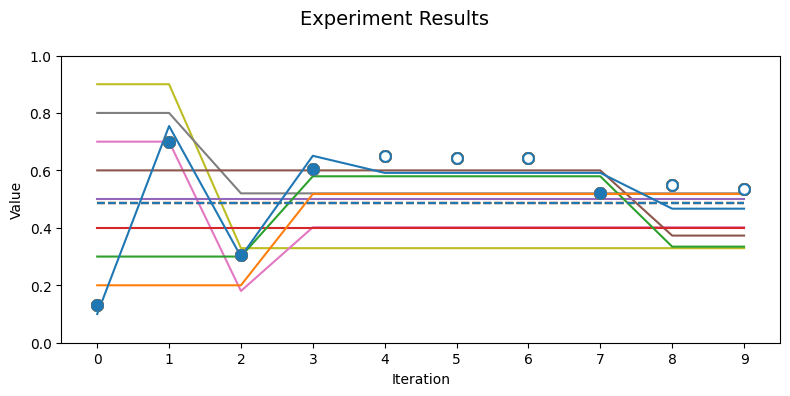

In [44]:
models = [
    ReplaceWhenWrong_HypothesisBank(
        history=(_hst:=HistoryManager(max_memory_length=None)),
        updater= UpdateConsistantWithData(data_list=_hst),
        selector=HypothesisOffset_StimulusSelector(sampling_bias=0.1),
        initial_hypothesis= Hypothesis(category_boundary=h)
    )
    for h in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
]
# models = [
#     ReplaceWhenWrong_HypothesisBank(
#         history=(_hst:=HistoryManager(max_memory_length=None)),
#         updater= UpdateConsistantWithData(data_list=_hst),
#         selector=HistoricallyInformedHypothesisOffset_StimulusSelector(sampling_bias=0.1,history=_hst),
#         initial_hypothesis= Hypothesis(category_boundary=h)
#     )
#     for h in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# ]

true_hypothesis = Hypothesis(0.4873)

results = run_experiment(
    models=models,
    true_hypothesis=true_hypothesis,
    num_iterations=10
)
plot_experiment_results(results, vertical=False, shared=True)


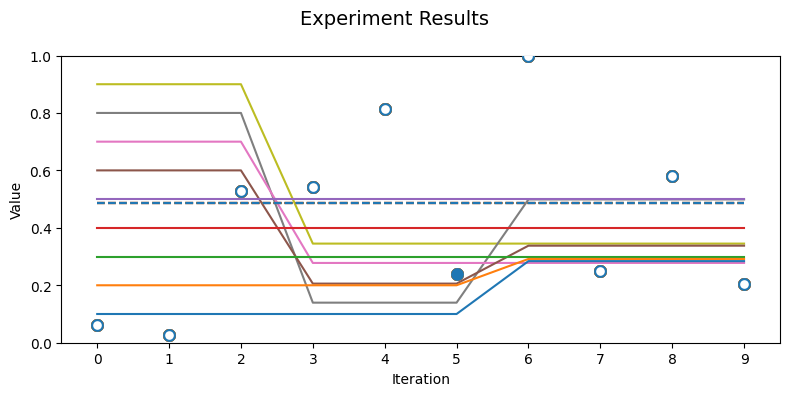

In [46]:
models = [
    ReplaceWhenWrong_HypothesisBank(
        history=(_hst:=HistoryManager(max_memory_length=None)),
        updater= UpdateConsistantWithData(data_list=_hst),
        selector=HypothesisOffset_StimulusSelector(sampling_bias=0.8),
        initial_hypothesis= Hypothesis(category_boundary=h)
    )
    for h in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
]


true_hypothesis = Hypothesis(0.4873)

results = run_experiment(
    models=models,
    true_hypothesis=true_hypothesis,
    num_iterations=10
)
plot_experiment_results(results, vertical=False, shared=True)

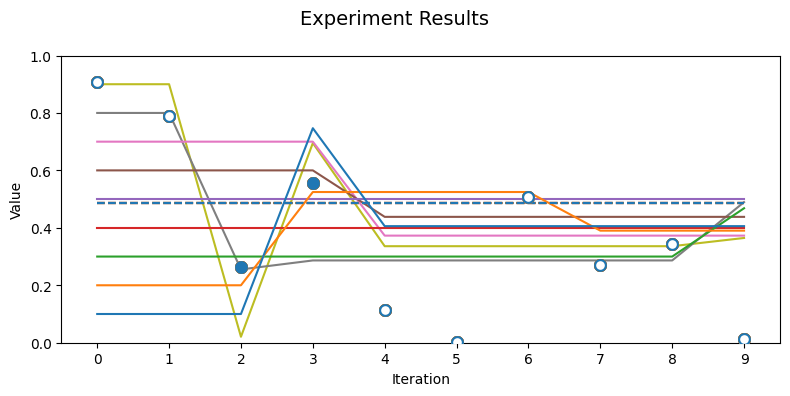

In [48]:
models = [
    ReplaceWhenWrong_HypothesisBank(
        history=(_hst:=HistoryManager(max_memory_length=None)),
        updater= UpdateConsistantWithData(data_list=_hst),
        selector=Random_StimulusSelector(),
        initial_hypothesis= Hypothesis(category_boundary=h)
    )
    for h in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
]


true_hypothesis = Hypothesis(0.4873)

results = run_experiment(
    models=models,
    true_hypothesis=true_hypothesis,
    num_iterations=10
)
plot_experiment_results(results, vertical=False, shared=True)

### Graph All Results

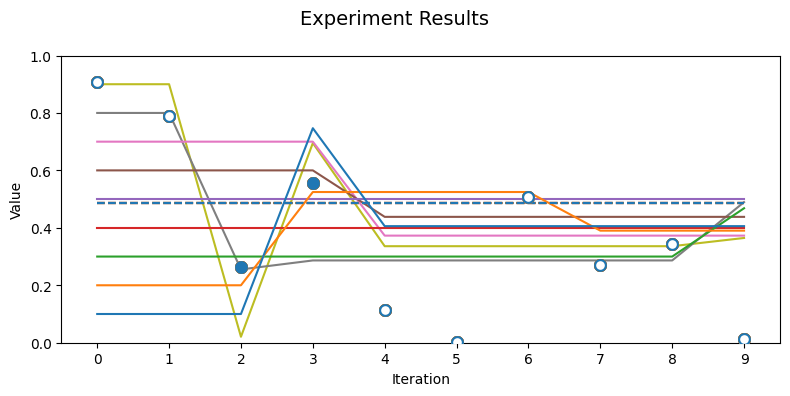

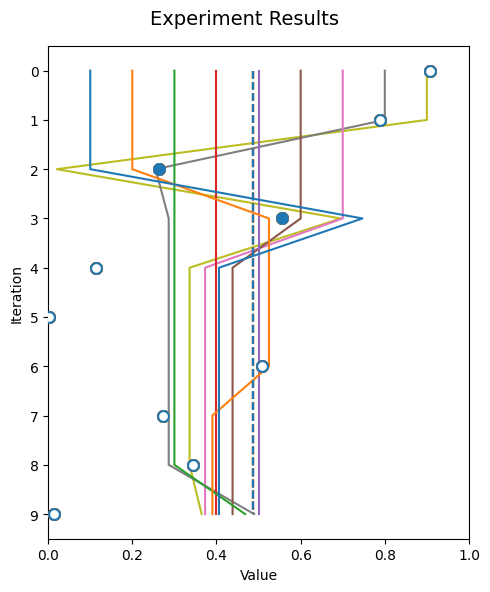

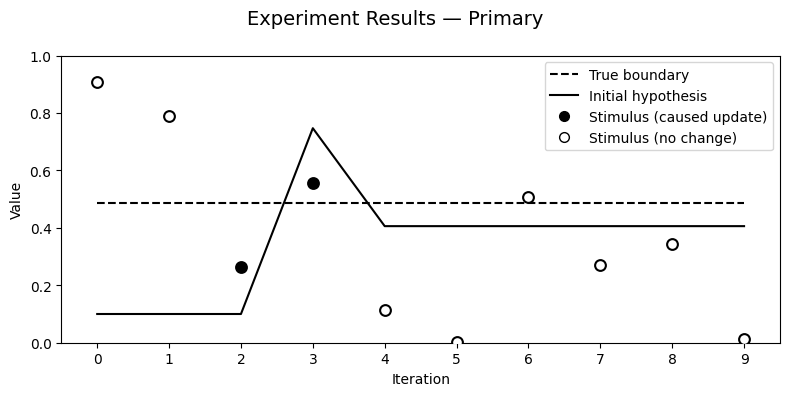

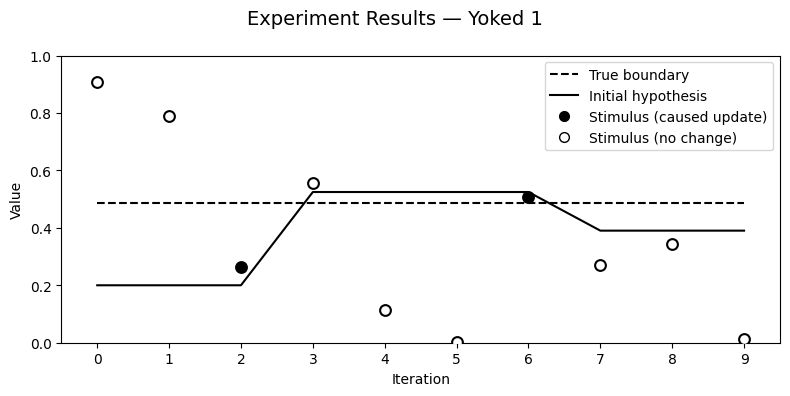

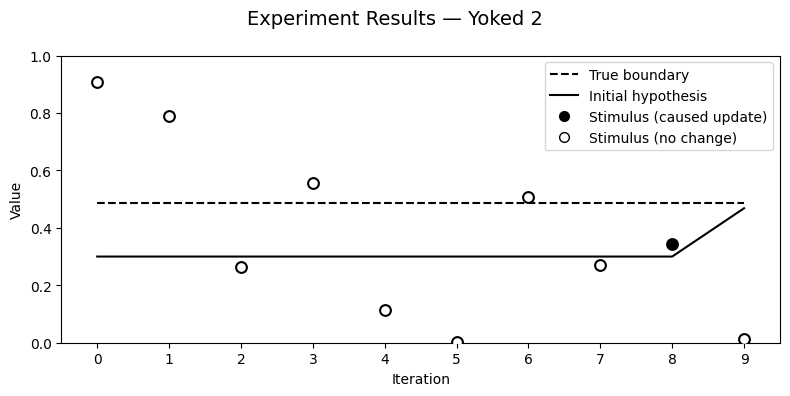

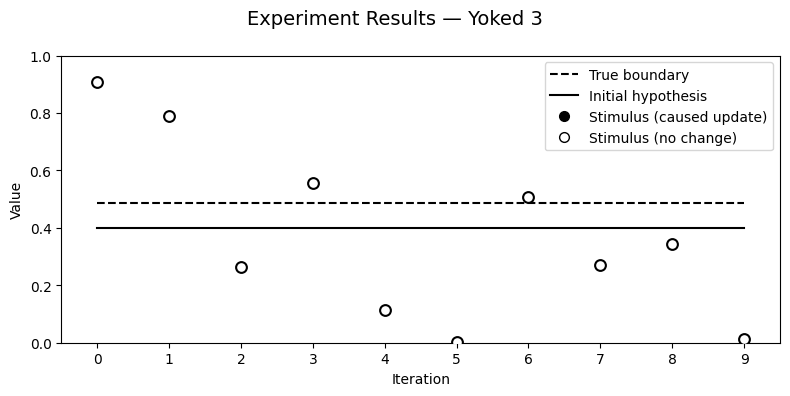

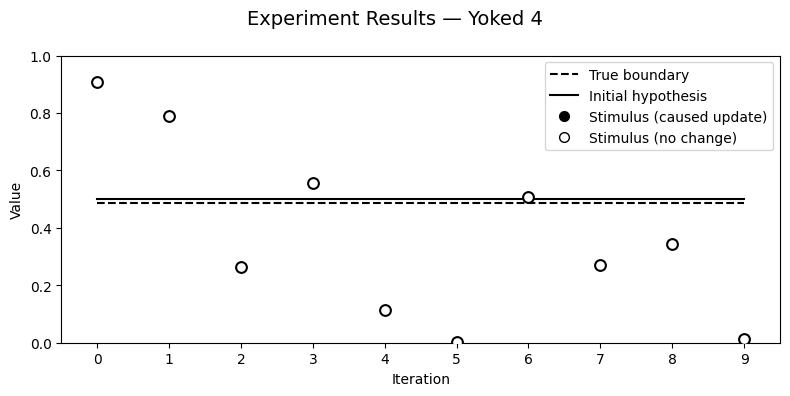

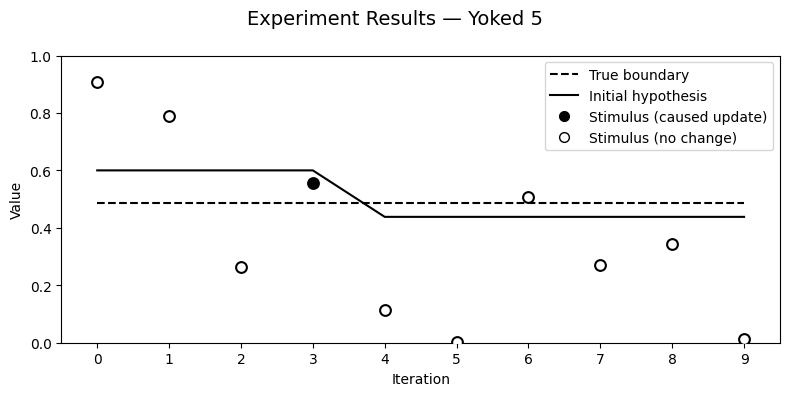

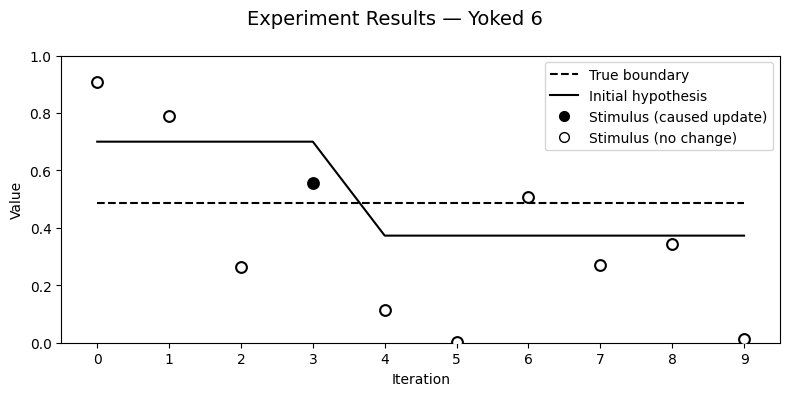

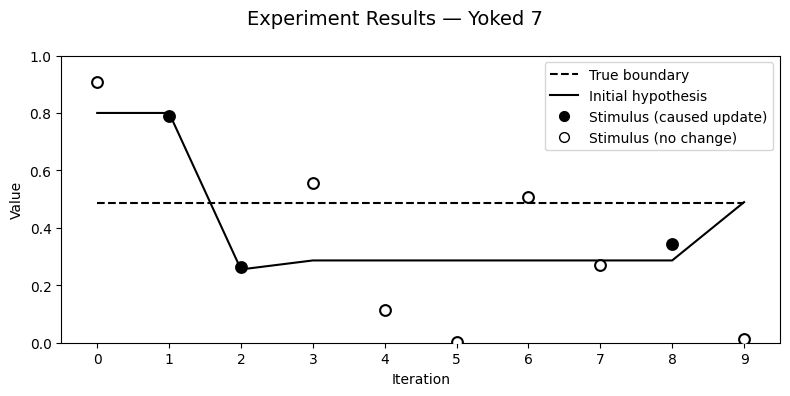

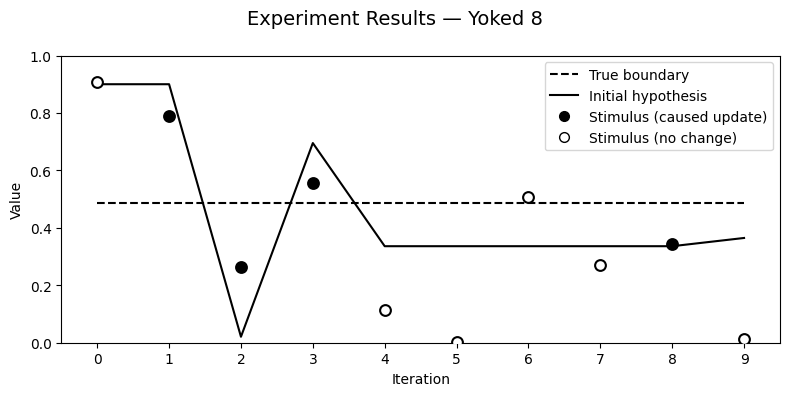

In [49]:
plot_experiment_results(results, vertical=False, shared=True)
plot_experiment_results(results, vertical=True, shared=True)
plot_experiment_results(results, vertical=False, shared=False)